Marka karşılaştırma özeti oluşturuldu.
Dosya: marka_karsilastirma_ozeti.xlsx


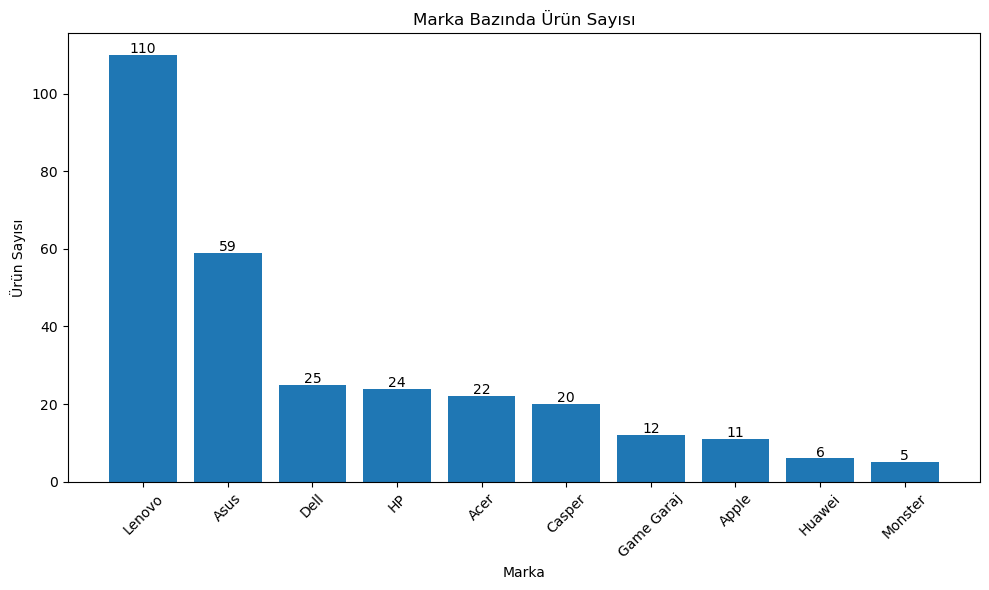

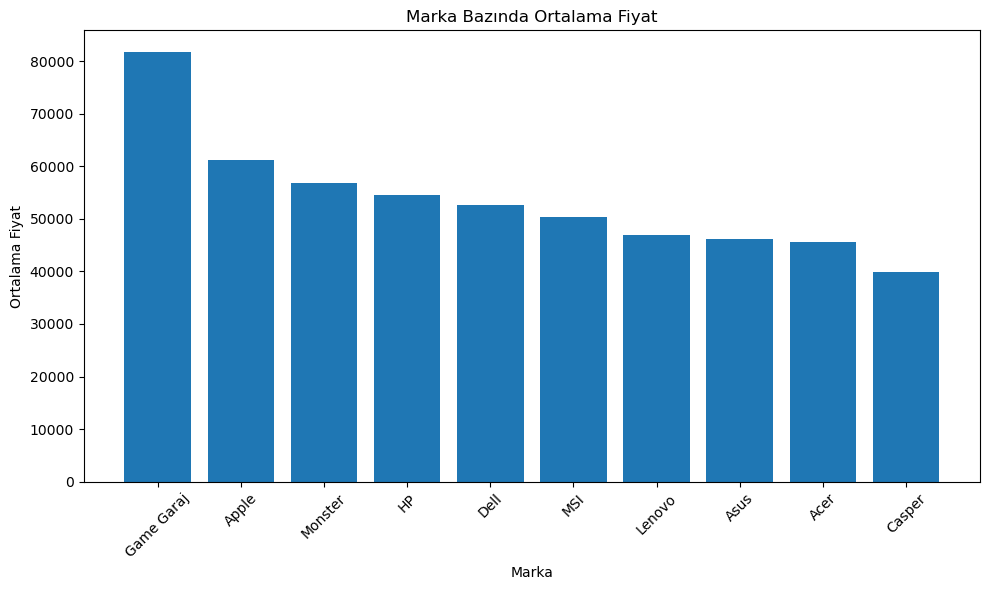

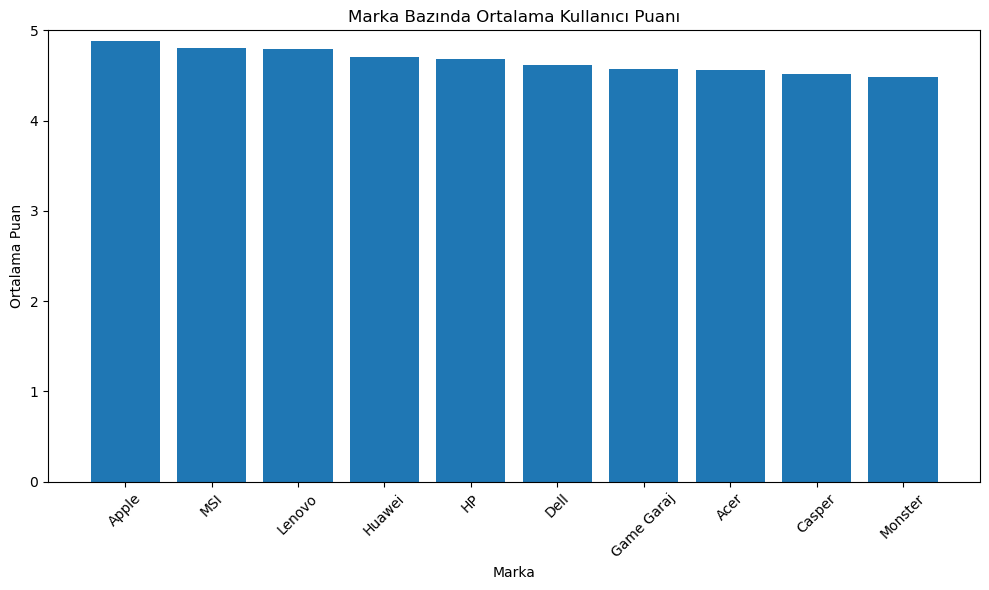

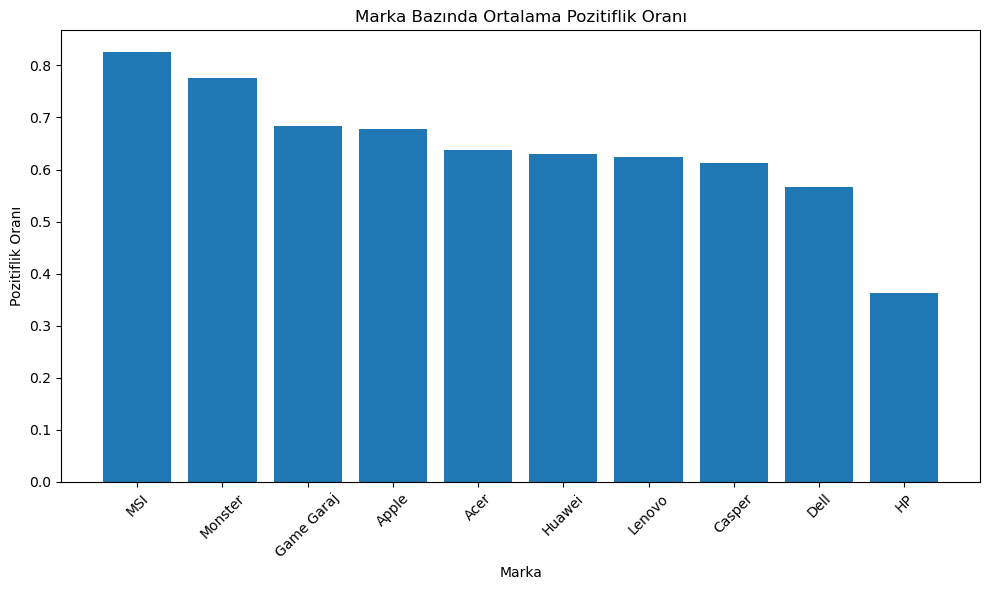

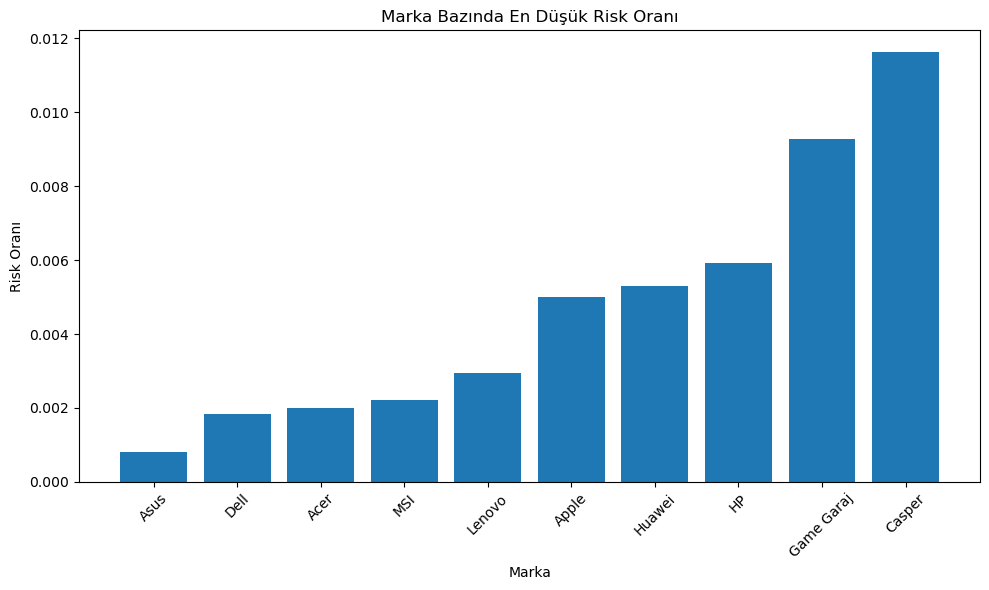

Marka karşılaştırma grafikleri oluşturuldu.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# ==============================
# DOSYA AYARLARI
# ==============================

GIRIS_DOSYASI = "analiz_verisi.xlsx"
CIKTI_KLASORU = "grafikler"

os.makedirs(CIKTI_KLASORU, exist_ok=True)

df = pd.read_excel(GIRIS_DOSYASI)

# ==============================
# TEMEL FİLTRE
# ==============================

df = df[df["marka"].notna()]
df = df[df["marka"] != "Bulunamadı"]

# Çok az ürünü olan markaları analizden çıkar
marka_sayilari = df["marka"].value_counts()
gecerli_markalar = marka_sayilari[marka_sayilari >= 3].index

df_marka = df[df["marka"].isin(gecerli_markalar)]

# ==============================
# MARKA ÖZET TABLOSU
# ==============================

marka_ozet = df_marka.groupby("marka").agg(
    urun_sayisi=("ürün_adı", "count"),
    ortalama_fiyat=("fiyat_sayisal", "mean"),
    ortalama_puan=("puan_sayisal", "mean"),
    ortalama_yorum_sayisi=("yorum_sayisi_sayisal", "mean"),
    ortalama_pozitiflik=("pozitiflik_orani", "mean"),
    ortalama_negatiflik=("negatiflik_orani", "mean"),
    ortalama_risk=("risk_orani", "mean"),
    ortalama_memnuniyet=("yorum_memnuniyet_skoru", "mean")
).reset_index()

marka_ozet.to_excel("marka_karsilastirma_ozeti.xlsx", index=False)

print("Marka karşılaştırma özeti oluşturuldu.")
print("Dosya: marka_karsilastirma_ozeti.xlsx")


# ==============================
# GRAFİK 1: ÜRÜN SAYISI
# ==============================

urun_sayisi = marka_ozet.sort_values("urun_sayisi", ascending=False).head(10)

plt.figure(figsize=(10, 6))
plt.bar(urun_sayisi["marka"], urun_sayisi["urun_sayisi"])
plt.title("Marka Bazında Ürün Sayısı")
plt.xlabel("Marka")
plt.ylabel("Ürün Sayısı")
plt.xticks(rotation=45)

for i, value in enumerate(urun_sayisi["urun_sayisi"]):
    plt.text(i, value + 0.5, str(value), ha="center")

plt.tight_layout()
plt.savefig(f"{CIKTI_KLASORU}/marka_urun_sayisi.png", dpi=300)
plt.show()


# ==============================
# GRAFİK 2: ORTALAMA FİYAT
# ==============================

ortalama_fiyat = marka_ozet.sort_values("ortalama_fiyat", ascending=False).head(10)

plt.figure(figsize=(10, 6))
plt.bar(ortalama_fiyat["marka"], ortalama_fiyat["ortalama_fiyat"])
plt.title("Marka Bazında Ortalama Fiyat")
plt.xlabel("Marka")
plt.ylabel("Ortalama Fiyat")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(f"{CIKTI_KLASORU}/marka_karsilastirma_ortalama_fiyat.png", dpi=300)
plt.show()


# ==============================
# GRAFİK 3: ORTALAMA PUAN
# ==============================

ortalama_puan = marka_ozet.sort_values("ortalama_puan", ascending=False).head(10)

plt.figure(figsize=(10, 6))
plt.bar(ortalama_puan["marka"], ortalama_puan["ortalama_puan"])
plt.title("Marka Bazında Ortalama Kullanıcı Puanı")
plt.xlabel("Marka")
plt.ylabel("Ortalama Puan")
plt.xticks(rotation=45)
plt.ylim(0, 5)
plt.tight_layout()
plt.savefig(f"{CIKTI_KLASORU}/marka_karsilastirma_ortalama_puan.png", dpi=300)
plt.show()


# ==============================
# GRAFİK 4: POZİTİFLİK ORANI
# ==============================

pozitiflik = marka_ozet.sort_values("ortalama_pozitiflik", ascending=False).head(10)

plt.figure(figsize=(10, 6))
plt.bar(pozitiflik["marka"], pozitiflik["ortalama_pozitiflik"])
plt.title("Marka Bazında Ortalama Pozitiflik Oranı")
plt.xlabel("Marka")
plt.ylabel("Pozitiflik Oranı")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(f"{CIKTI_KLASORU}/marka_pozitiflik_orani.png", dpi=300)
plt.show()


# ==============================
# GRAFİK 5: RİSK ORANI
# ==============================

risk = marka_ozet.sort_values("ortalama_risk", ascending=True).head(10)

plt.figure(figsize=(10, 6))
plt.bar(risk["marka"], risk["ortalama_risk"])
plt.title("Marka Bazında En Düşük Risk Oranı")
plt.xlabel("Marka")
plt.ylabel("Risk Oranı")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(f"{CIKTI_KLASORU}/marka_risk_orani.png", dpi=300)
plt.show()

print("Marka karşılaştırma grafikleri oluşturuldu.")